In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
# --- Load dataset ---
# Example format:
# Columns: Species, temp_1, temp_2,..., temp_n
# Rows: Arabian smooth-hound, 0.01527, 0.01518,...
data = pd.read_csv("../../data/shark_dataset.csv")

# --- Features = Fluorescence values, Label = Species ---
X_raw = data.drop(columns=["Species"])
y = data["Species"]

# --- Drop species with <2 samples to allow stratification ---
counts = y.value_counts()
valid_classes = counts[counts >= 2].index
mask = y.isin(valid_classes)
X_raw = X_raw[mask]
y = y[mask]

In [27]:
# --- Feature engineering ---

from scipy.integrate import simpson

def feature_engineering(df):
    features = pd.DataFrame()
    temps = df.columns.astype(float)

    features['max'] = df.max(axis=1)
    features['min'] = df.min(axis=1)
    features['mean'] = df.mean(axis=1)
    features['std'] = df.std(axis=1)
    
    features['auc'] = df.apply(lambda row: simpson(row, temps), axis=1)
    features['centroid'] = df.apply(lambda row: np.sum(row*temps)/np.sum(row), axis=1)
    
    features['temp_peak'] = df.apply(lambda row: temps[np.argmax(row)], axis=1)
    features['fwhm'] = df.apply(lambda row: np.sum(row > 0.5*row.max()), axis=1)
    features['rise_time'] = df.apply(lambda row: np.argmax(row), axis=1)
    features['decay_time'] = df.apply(lambda row: len(row) - np.argmax(row[::-1]), axis=1)
    
    features['auc_left'] = df.apply(lambda row: simpson(row[:np.argmax(row)+1], temps[:np.argmax(row)+1]), axis=1)
    features['auc_right'] = df.apply(lambda row: simpson(row[np.argmax(row):], temps[np.argmax(row):]), axis=1)
    
    features['asymmetry'] = features['auc_left'] / (features['auc_right'] + 1e-8)
    return features

X_features = feature_engineering(X_raw)

def enhanced_features(features):
    enhanced = features.copy()
    
    # Interaction features from top performers
    enhanced['fwhm_rise_ratio'] = features['fwhm'] / (features['rise_time'] + 1e-8)
    enhanced['peak_temp_std'] = features['temp_peak'] * features['std']
    enhanced['asymmetry_fwhm'] = features['asymmetry'] * features['fwhm']
    enhanced['rise_decay_ratio'] = features['rise_time'] / (features['decay_time'] + 1e-8)
    
    return enhanced

X_features = enhanced_features(X_features)

In [28]:
# --- Train/test split with stratification (keeps species balanced across sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=8, stratify=y
)

# Note: Model parameters are defined and trained in the next cell

In [29]:
# --- Define hyperparameters for optimized ExtraTrees ---
from sklearn.ensemble import ExtraTreesClassifier

RANDOM_STATE = 8

best_params = {
    'n_estimators': 900,
    'max_depth': 40,
    'min_samples_split': 4,
    'min_samples_leaf': 2,
    'max_features': 0.5,
    'class_weight': 'balanced_subsample',
    'random_state': RANDOM_STATE,
    'n_jobs': -1  # use all CPU cores
}

# --- Train best model (ExtraTrees) with specified parameters ---
best_rf = ExtraTreesClassifier(**best_params)
best_rf.fit(X_train, y_train)

y_test_pred_check = best_rf.predict(X_test)
print("Model: ExtraTreesClassifier (optimized)")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_test_pred_check))

Model: ExtraTreesClassifier (optimized)
Best parameters: {'n_estimators': 900, 'max_depth': 40, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 0.5, 'class_weight': 'balanced_subsample', 'random_state': 8, 'n_jobs': -1}
Test accuracy: 0.8702290076335878


In [30]:
# --- Predictions on test set ---
sample_idx = np.random.choice(X_test.index, size=5, replace=False)
for idx in sample_idx:
    probs = best_rf.predict_proba([X_test.loc[idx]])[0]
    sorted_idx = np.argsort(probs)[::-1]
    
    print(f"Row {idx} | True: {y_test.loc[idx]} | Pred: {best_rf.classes_[sorted_idx[0]]} ({probs[sorted_idx[0]]*100:.1f}%)")
    for i in sorted_idx[:5]:
        print(f"  {best_rf.classes_[i]:<25} {probs[i]*100:.3f}%")
    print()

Row 279 | True: Gulper shark | Pred: Gulper shark (85.3%)
  Gulper shark              85.290%
  Arabian smooth-hound      8.606%
  Spotted Eagleray          2.272%
  Hooktooth shark           2.072%
  Blackspotted smooth-hound 0.951%

Row 228 | True: Great hammerhead shark | Pred: Great hammerhead shark (99.7%)
  Great hammerhead shark    99.687%
  Night shark               0.144%
  Scalloped hammerhead shark 0.087%
  Thornback ray             0.081%
  Zebra shark               0.000%

Row 635 | True: Whitecheeck shark | Pred: Whitecheeck shark (39.2%)
  Whitecheeck shark         39.223%
  Spotted Eagleray          15.712%
  Blackspotted smooth-hound 13.241%
  Grey reef shark           7.601%
  Copper shark              6.550%



c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


Row 267 | True: Grey reef shark | Pred: Grey reef shark (55.3%)
  Grey reef shark           55.320%
  Copper shark              18.243%
  Roughskin dogfish         10.287%
  Porbeagle shark           6.590%
  Japanese topeshark        3.325%

Row 92 | True: Blue shark | Pred: Blue shark (65.9%)
  Blue shark                65.859%
  Scalloped hammerhead shark 19.169%
  Scalloped bonnethead shark 4.030%
  Smooth hammerhead shark   3.319%
  Atlantic Sharpnose shark  2.209%



c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but ExtraTreesClassifier was fitted with feature names
  warnings.warn(


In [31]:
# --- Evaluation ---
y_test_pred = best_rf.predict(X_test)
print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


Test Accuracy: 0.8702290076335878

Classification Report:
                             precision    recall  f1-score   support

      Arabian smooth-hound       1.00      1.00      1.00         1
  Atlantic Sharpnose shark       1.00      1.00      1.00         1
      Blackchin guitarfish       1.00      1.00      1.00         2
           Blacknose shark       1.00      1.00      1.00         1
 Blackspotted smooth-hound       1.00      1.00      1.00         1
       Blacktip reef shark       1.00      1.00      1.00         1
            Blacktip shark       0.71      0.83      0.77         6
                Blue shark       1.00      0.86      0.92         7
          Bonnethead shark       0.00      0.00      0.00         1
       Bowmouth guitarfish       0.33      1.00      0.50         1
  Brownbanded bamboo shark       1.00      0.50      0.67         2
                Bull shark       1.00      1.00      1.00         6
      Caribbean reef shark       1.00      1.00      1.

c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

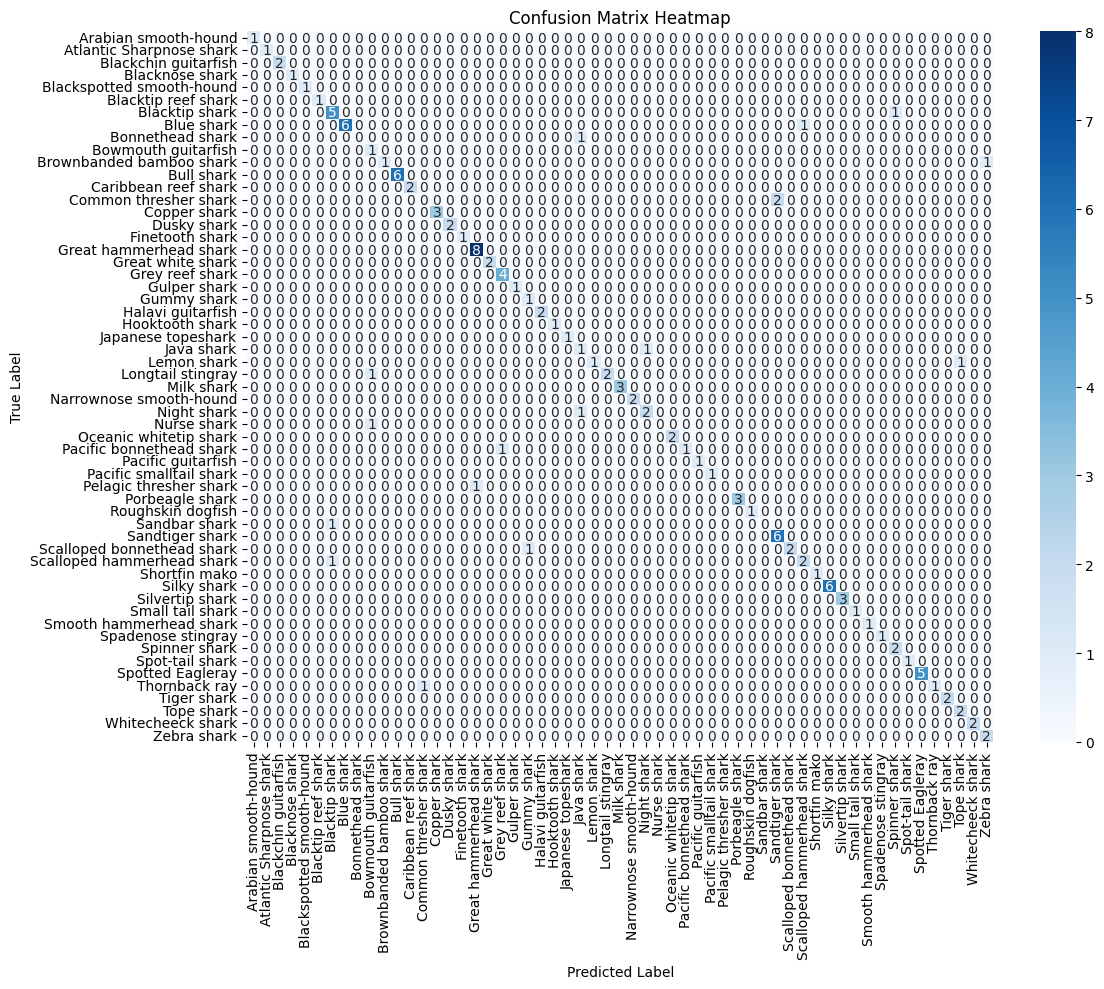

In [32]:
# --- Confusion matrix for species-level performance ---
cm = confusion_matrix(y_test, y_test_pred, labels=best_rf.classes_)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=best_rf.classes_, yticklabels=best_rf.classes_)
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Confusion Matrix Heatmap")
plt.tight_layout()
plt.show()

In [33]:
# --- Feature importance ---
importances = pd.Series(best_rf.feature_importances_, index=X_features.columns)
print("\nTop 10 Important Features:\n", importances.nlargest(10))

# Feature Selection
print("\n--- Testing with Feature Selection ---")
top_n = 8  # experiment with 6, 8, 10
top_features = importances.nlargest(top_n).index
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

# Retrain with selected features using same parameters
rf_selected = RandomForestClassifier(**best_params)
rf_selected.fit(X_train_selected, y_train)
y_pred_selected = rf_selected.predict(X_test_selected)
print(f"Accuracy with top {top_n} features:", accuracy_score(y_test, y_pred_selected))


Top 10 Important Features:
 fwhm                0.117741
fwhm_rise_ratio     0.112682
temp_peak           0.085222
asymmetry_fwhm      0.085218
decay_time          0.083870
rise_time           0.083721
asymmetry           0.072594
rise_decay_ratio    0.059956
max                 0.050019
std                 0.048050
dtype: float64

--- Testing with Feature Selection ---
Accuracy with top 8 features: 0.8396946564885496


c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


5-Fold Stratified Cross-Validation Results
ExtraTreesClassifier (Optimized)
Fold 1: 0.8779 (87.79%)
Fold 2: 0.8538 (85.38%)
Fold 3: 0.9000 (90.00%)
Fold 4: 0.8769 (87.69%)
Fold 5: 0.8846 (88.46%)
--------------------------------------------------
Mean accuracy: 0.8786 (87.86%)
Std deviation: 0.0149


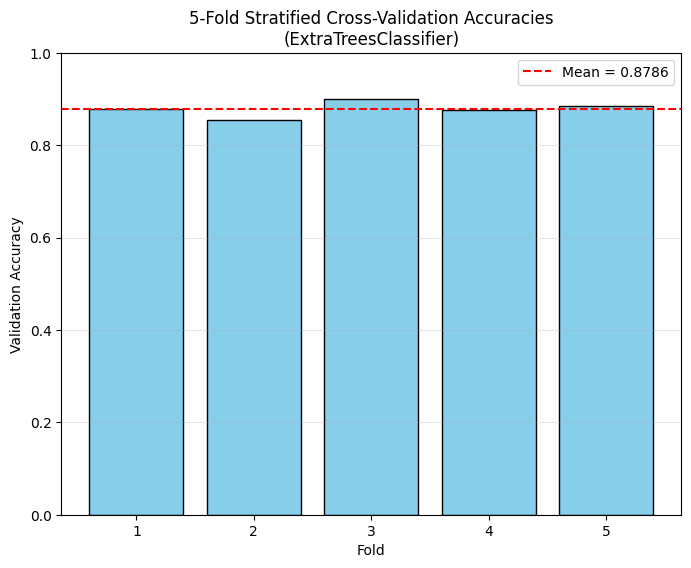

In [34]:
# --- Stratified K-Fold Cross-Validation ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=8)
scores = cross_val_score(best_rf, X_features, y, cv=cv, scoring='accuracy')

print("=" * 50)
print("5-Fold Stratified Cross-Validation Results")
print("ExtraTreesClassifier (Optimized)")
print("=" * 50)

# Record individual fold accuracies
fold_accuracies = {}
for fold, acc in enumerate(scores, 1):
    print(f"Fold {fold}: {acc:.4f} ({acc*100:.2f}%)")
    fold_accuracies[f'fold_{fold}'] = float(acc)

print("-" * 50)
print(f"Mean accuracy: {scores.mean():.4f} ({scores.mean()*100:.2f}%)")
print(f"Std deviation: {scores.std():.4f}")
print("=" * 50)

# Store results
cv_results = {
    'model': 'ExtraTreesClassifier',
    'fold_accuracies': fold_accuracies,
    'mean_accuracy': float(scores.mean()),
    'std_deviation': float(scores.std()),
    'all_scores': scores.tolist()
}

plt.figure(figsize=(8,6))
plt.bar(range(1, len(scores)+1), scores, color="skyblue", edgecolor="black")
plt.axhline(np.mean(scores), color="red", linestyle="--", label=f"Mean = {scores.mean():.4f}")
plt.xlabel("Fold")
plt.ylabel("Validation Accuracy")
plt.title("5-Fold Stratified Cross-Validation Accuracies\n(ExtraTreesClassifier)")
plt.ylim([0, 1])
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\conno\Documents\vscodeprojects\SharkMQP26\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

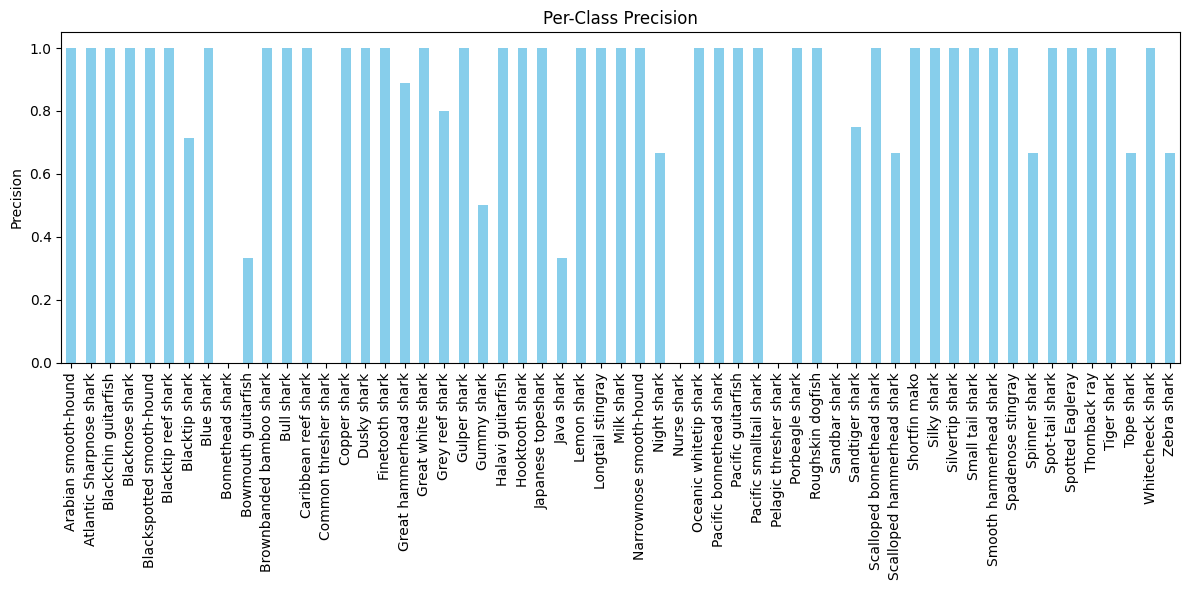

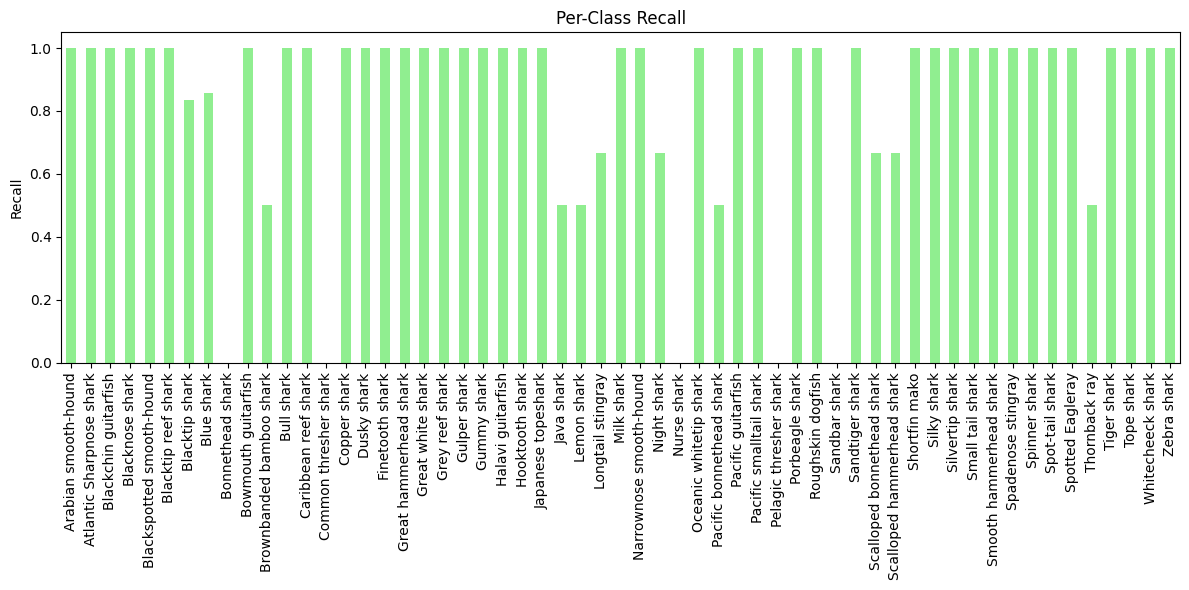

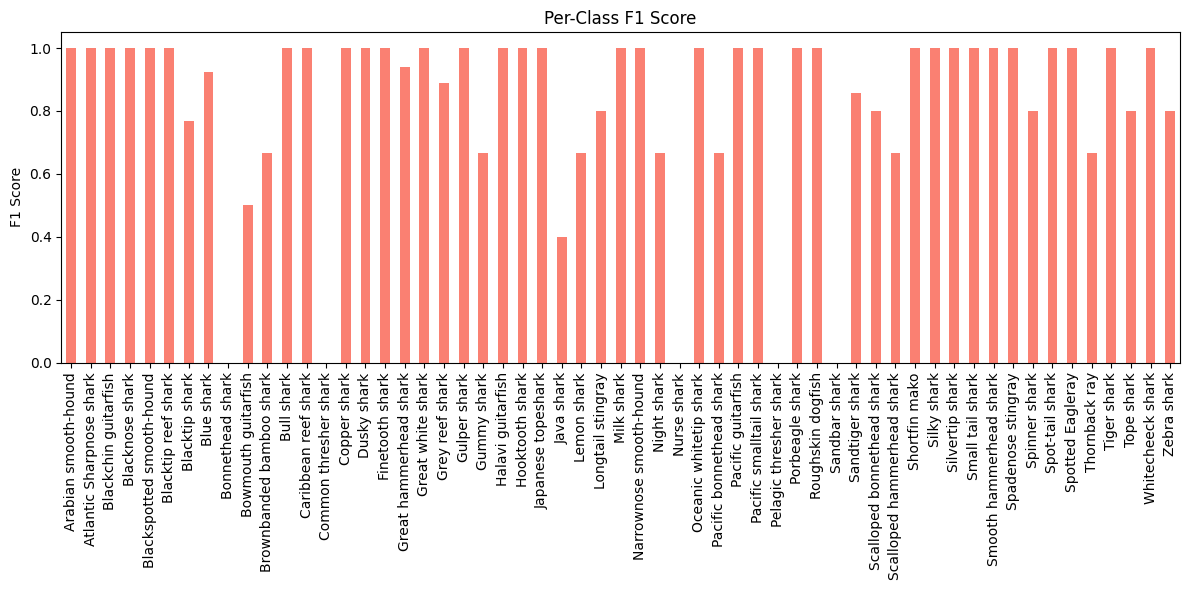

In [35]:
# --- Per-class precision, recall, and F1 ---
report = classification_report(y_test, y_test_pred, output_dict=True)
df = pd.DataFrame(report).transpose().drop(["accuracy", "macro avg", "weighted avg"])
precision = df["precision"]
recall = df["recall"]
f1 = df["f1-score"]

# Plot precision
plt.figure(figsize=(12,6))
precision.plot(kind="bar", color="skyblue")
plt.title("Per-Class Precision")
plt.ylabel("Precision")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot recall
plt.figure(figsize=(12,6))
recall.plot(kind="bar", color="lightgreen")
plt.title("Per-Class Recall")
plt.ylabel("Recall")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot F1 score
plt.figure(figsize=(12,6))
f1.plot(kind="bar", color="salmon")
plt.title("Per-Class F1 Score")
plt.ylabel("F1 Score")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [36]:
import pickle
import json
from pathlib import Path

# Save best model with accuracy in filename
test_acc = accuracy_score(y_test, y_test_pred)
acc_str = f"{test_acc*100:.2f}".replace('.', '')

output_dir = Path(".")
model_filename = f"extratrees_optimized_{acc_str}.pkl"
model_path = output_dir / model_filename

with open(model_path, 'wb') as f:
    pickle.dump(best_rf, f)

print(f"✅ Model saved: {model_path}")
print(f"   Test Accuracy: {test_acc*100:.2f}%")

# Save 5-fold cross-validation results to JSON
results_filename = "extratrees_cv_results.json"
results_path = output_dir / results_filename

with open(results_path, 'w') as f:
    json.dump(cv_results, f, indent=2)

print(f"✅ CV Results saved: {results_path}")
print(f"\n5-Fold CV Summary:")
print(f"   Mean Accuracy: {cv_results['mean_accuracy']:.4f}")
print(f"   Std Deviation: {cv_results['std_deviation']:.4f}")
print(f"\nIndividual Fold Accuracies:")
for fold, acc in cv_results['fold_accuracies'].items():
    print(f"   {fold}: {acc:.4f}")

✅ Model saved: extratrees_optimized_8702.pkl
   Test Accuracy: 87.02%
✅ CV Results saved: extratrees_cv_results.json

5-Fold CV Summary:
   Mean Accuracy: 0.8786
   Std Deviation: 0.0149

Individual Fold Accuracies:
   fold_1: 0.8779
   fold_2: 0.8538
   fold_3: 0.9000
   fold_4: 0.8769
   fold_5: 0.8846
